# PoTeC decoder-LM pipeline — interactive exploration

Notebook twin of `src/main.py`. Same modules, but the data is kept live so you can
poke at it: filter the words/reading tables, recompute surprisal–RT correlations
for any reader group / domain, and sweep the attention layer curve — all inline.

The heavy DAPT fine-tuning of `main.py` (step 4) is **off by default** here; the
exploratory steps (1–3, 5) run on CPU in a couple of minutes with `german-gpt2`.
Flip `RUN_DAPT = True` in the last section if you have a GPU.

Interactivity uses `ipywidgets` when present and falls back to plain editable
parameter cells otherwise (`uv pip install ipywidgets` to get the sliders).

## Setup

In [1]:
import sys
from pathlib import Path

# notebook lives in notebooks/ — put the project root on the path so `import src` works
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

from src import config
from src.features import data
from src.features import reading_time as rt
from src.features import surprisal as su
from src.features import attention as at
from src.analysis import correlation as co
from src.analysis import viz

# small helper: use ipywidgets.interact when available, else just call f(**defaults)
try:
    from ipywidgets import interact  # noqa: F401
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    def interact(_f=None, **kw):
        defaults = {k: (v[0] if isinstance(v, (list, tuple)) else v) for k, v in kw.items()}
        print(f"(no ipywidgets — running with {defaults})")
        return _f(**defaults) if _f else None

print("widgets:", HAVE_WIDGETS, "| project root:", PROJECT_ROOT)

widgets: True | project root: /home/ely/Documents/vault/04-lang-comp-cog/02-project


In [2]:
# ---- knobs for the whole notebook -------------------------------------------
MEASURE = "TFT"             # reading-time column: TFT (=TRT), FPRT, ...
MODEL_NAME = config.MODELS["german-gpt2"]   # swap to config.MODELS["llammlein-1b"] for the 1B
MODEL_NAME

'dbmdz/german-gpt2'

## Step 1 — load & clean the data

`words` = PoTeC stimuli (one row per word per text). `rm_raw` = per-reader reading
measures (~900 files). `rm` = cleaned (sentence edges, skips, IQR outliers dropped).

In [3]:
words = data.load_word_features()
rm_raw = data.load_reading_measures()
rm = rt.clean_reading_times(rm_raw, MEASURE)

print(f"words={len(words)}  raw_rows={len(rm_raw)}  cleaned={len(rm)} ({len(rm)/len(rm_raw):.1%} kept)")
words.head()

words=1895  raw_rows=142125  cleaned=109708 (77.2% kept)


,word,word_length,word_index_in_text,word_index_in_sent,sent_index_in_text,text_id,text_domain,is_sent_beginning,is_sent_end,is_expert_technical_term,is_general_technical_term,STTS_PoS_tag
0,Um,2,1,1,1,b0,biology,1,0,0,0,KOUI
1,das,3,2,2,1,b0,biology,0,0,0,0,ART
2,Vorhandensein,13,3,3,1,b0,biology,0,0,0,0,NN
3,der,3,4,4,1,b0,biology,0,0,0,0,ART
4,Polymerasekettenreaktion-Produkte,33,5,5,1,b0,biology,0,0,1,0,NN


In [4]:
# per-word reading-time aggregates by reader group (all / experts / experts-by-level)
agg = rt.aggregate_rt(rm, MEASURE)
pd.DataFrame(
    {grp: {"n_words": len(v), f"mean_{MEASURE}": round(v[f'mean_{MEASURE}'].mean(), 1)}
     for grp, v in agg.items()}
).T

,n_words,mean_TFT
all,1701.0,604.1
experts,1701.0,570.4
experts_undergraduate,1701.0,589.4
experts_graduate,1701.0,559.0


### Explore the words table
Pick a text and a domain; see its words and how many readers each was fixated by.

In [5]:
text_ids = sorted(words["text_id"].unique().tolist())

def show_text(text_id=text_ids[0], n=20):
    sub = words[words["text_id"] == text_id].sort_values("word_index_in_text")
    cols = [c for c in ["word_index_in_text", "word", "text_domain", "is_sent_beginning", "is_sent_end"] if c in sub.columns]
    display(sub[cols].head(int(n)))
    print(f"{len(sub)} words in {text_id}")

interact(show_text, text_id=text_ids, n=(5, 60, 5));

interactive(children=(Dropdown(description='text_id', options=('b0', 'b1', 'b2', 'b3', 'b4', 'b5', 'p0', 'p1',…

## Step 2 — surprisal
Load the causal LM once and compute per-word surprisal (prompt=None baseline).
`german-gpt2` is small enough for CPU; the cell caches the model in `_LM`.

In [6]:
# load + cache so re-running cells below doesn't re-download/re-load
try:
    model, tok = _LM
except NameError:
    model, tok = su.load_causal_lm(MODEL_NAME)
    _LM = (model, tok)

surp = su.compute_surprisal(words, model, tok)
surp.head()

,text_id,word_index_in_text,surprisal
0,b0,2,6.670333
1,b0,3,11.624302
2,b0,4,3.556032
3,b0,5,37.965656
4,b0,6,9.998916


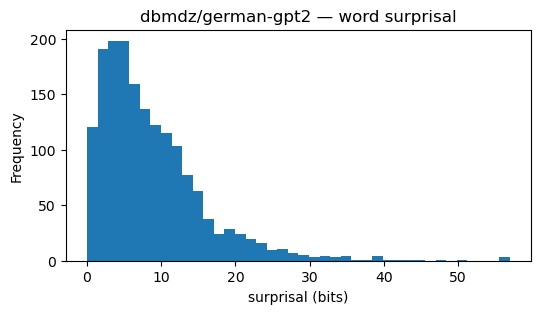

In [7]:
# distribution of word surprisal
fig, ax = plt.subplots(figsize=(6, 3))
surp["surprisal"].plot.hist(bins=40, ax=ax)
ax.set(xlabel="surprisal (bits)", title=f"{MODEL_NAME} — word surprisal")
plt.show()

## Step 5 — surprisal vs reading time
Merge surprisal onto the cleaned reading measures, then explore the correlation
for any reader group / domain-only filter / aggregation mode.

In [8]:
merged = co.merge_surprisal_rt(surp, rm)

# the full correlation grid main.py prints, kept live
rows = []
for grp in ["all", "experts", "novices"]:
    for dom_only in (False, True):
        r = co.correlate_surprisal(merged, participants=grp, domain_only=dom_only, mode="mean", measure=MEASURE)
        rows.append({"group": grp, "domain_only": dom_only, **r})
corr_df = pd.DataFrame(rows)[["group", "domain_only", "n", "pearson", "spearman"]]
corr_df

,group,domain_only,n,pearson,spearman
0,all,False,1696,0.695662,0.597525
1,all,True,375,0.648665,0.610004
2,experts,False,1696,0.678724,0.574359
3,experts,True,375,0.632532,0.577239
4,novices,False,1696,0.687764,0.603432
5,novices,True,375,0.634192,0.625249


In [9]:
# interactive: pick the slice, get the correlation + binned scatter with OLS fit
def explore_corr(group="all", domain="all", domain_only=False, mode="mean"):
    r = co.correlate_surprisal(
        merged, participants=group, domain=domain, domain_only=domain_only, mode=mode, measure=MEASURE
    )
    print(f"n={r['n']}  pearson={r['pearson']:.3f} (p={r['pearson_p']:.1e})  "
          f"spearman={r['spearman']:.3f} (p={r['spearman_p']:.1e})")
    df = co._filter_domain_only(
        co._filter_participants(co._filter_domain(merged, domain), group), domain_only
    )
    agg_words = co._aggregate_words(df, MEASURE, mode)
    fig, ax = plt.subplots(figsize=(6, 4))
    viz.surprisal_scatter(agg_words, ax=ax)
    ax.set_title(f"{group} | domain={domain} | domain_only={domain_only}")
    plt.show()

interact(
    explore_corr,
    group=["all", "experts", "novices"],
    domain=["all", "physics", "biology"],
    domain_only=[False, True],
    mode=["mean", "median"],
);

interactive(children=(Dropdown(description='group', options=('all', 'experts', 'novices'), value='all'), Dropd…

In [10]:
# OLS slope: ms of reading time per bit of surprisal
fit = co.regress_rt(merged, participants="all", measure=MEASURE)
print(f"slope = {fit.params['surprisal']:.2f} ms/bit   R2 = {fit.rsquared:.3f}")
fit.summary().tables[1]

slope = 38.79 ms/bit   R2 = 0.484


,coef,std err,t,P>|t|,[0.025,0.975]
const,266.2650,10.982,24.246,0.000,244.726,287.804
surprisal,38.7908,0.973,39.857,0.000,36.882,40.700


## Step 3 — attention vs gaze
Reload the model with attention output on, extract per-word/per-layer attention,
build the sentence-relative eye-tracking features, and sweep the layer curve.

> Gaze features are normalized to their **within-sentence share** — this must match
> the attention sum-normalization or the correlation collapses (see `attention.py`).

In [11]:
# separate model handle with output_attentions=True
try:
    amodel, atok = _ALM
except NameError:
    amodel, atok = su.load_causal_lm(MODEL_NAME, attn=True)
    _ALM = (amodel, atok)

attn_df = at.extract_attention(words, amodel, atok, method="raw")
et_df = co.build_et_table(rm, participants="all")
attn_corr = co.correlate_attention(attn_df, et_df, attention_method="raw")
print("layers:", sorted(attn_df['layer'].unique().tolist()))
attn_corr.head()

/home/ely/.local/share/mamba/envs/eyebench/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:818: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_attentions` is. When `return_dict_in_generate` is not `True`, `output_attentions` is ignored.
  warnings.warn(


layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


,layer,feature,attention_method,spearman,p,n
0,0,FPRT,raw,0.660998,3.769668e-214,1701
1,0,TFT,raw,0.621817,1.403793e-182,1701
2,0,FFD,raw,0.678041,2.001649e-229,1701
3,0,SFD,raw,0.678137,7.615993e-229,1696
4,0,RPD_inc,raw,0.604542,4.868769e-170,1701


In [ ]:
# per-layer Spearman curve, one eye-tracking feature at a time
features = sorted(attn_corr["feature"].unique().tolist())
default_feat = "pca" if "pca" in features else features[0]

def show_layer_curve(feature=default_feat):
    fig, ax = plt.subplots(figsize=(7, 4))
    viz.attention_layer_curve(attn_corr, feature=feature, ax=ax)
    plt.show()

interact(show_layer_curve, feature=features);

interactive(children=(Dropdown(description='feature', index=6, options=('FFD', 'FPRT', 'RPD_inc', 'SFD', 'TFC'…

## Step 3c — attention-vs-gaze across DAPT checkpoints

Same attention-vs-gaze Spearman as Step 3, but recomputed with the **saved LoRA
checkpoints** under `artifacts/` (`{model}_{domain}_lora/checkpoint_00..02`).
`checkpoint_00` is the un-fine-tuned baseline; 01/02 are the first DAPT steps.

Two independent filters on the gaze side:

* **texts** — which text domain's words enter the correlation (physics / biology / all).
* **subjects** — which readers' fixations enter the across-reader **mean** reading
  time, filtered by the reader's own discipline (`reader_discipline_numeric`:
  physics=1, biology=0), independent of the texts filter.

`ckpt_domain` picks which adapter series (physics- or biology-DAPT) the checkpoints
come from. Attention extraction per checkpoint is cached in `_ATTN_CACHE`.

In [ ]:
import torch

# adapter series live in artifacts/{slug}_{domain}_lora/checkpoint_NN.
# config.ARTIFACTS_DIR is relative (resolved against cwd at run time); the
# notebook's cwd is notebooks/, so anchor it at PROJECT_ROOT explicitly.
slug = next(k for k, v in config.MODELS.items() if v == MODEL_NAME)
ARTIFACTS_DIR = PROJECT_ROOT / config.ARTIFACTS_DIR
CKPT_INDICES = [0, 1, 2]

def ckpt_path(ckpt_domain, index):
    return ARTIFACTS_DIR / f"{slug}_{ckpt_domain}_lora" / f"checkpoint_{index:02d}"

# cache extracted attention so re-running the widget doesn't reload models.
# checkpoint_00 is the shared un-fine-tuned baseline (seed-0 base + LoRA identity),
# so physics/biology index 0 reuse one "baseline" entry.
_ATTN_CACHE = {}

def attention_for_ckpt(ckpt_domain, index):
    key = ("baseline", 0) if index == 0 else (ckpt_domain, index)
    if key not in _ATTN_CACHE:
        path = ckpt_path(ckpt_domain, index)
        if not (path / "adapter_config.json").is_file():
            raise FileNotFoundError(f"no checkpoint at {path}")
        m, t = su.load_causal_lm(str(path), attn=True)
        _ATTN_CACHE[key] = at.extract_attention(words, m, t, method="raw")
        del m, t
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return _ATTN_CACHE[key]

print("checkpoint dirs found:")
for dom in ("physics", "biology"):
    have = [i for i in CKPT_INDICES if (ckpt_path(dom, i) / "adapter_config.json").is_file()]
    print(f"  {slug}_{dom}_lora: checkpoints {have}")

In [ ]:
# gaze-side eye-tracking table for a TEXTS (text_domain) + SUBJECTS (reader
# discipline) choice. SUBJECTS filters which readers enter the across-reader mean
# (eyetracking_features averages over readers); TEXTS filters which words are kept.
_DISC_CODE = {"physics": 1, "biology": 0}   # reader_discipline_numeric (see config.py)

def et_table(texts="all", subjects="all"):
    sub = rm if subjects == "all" else rm[rm["reader_discipline_numeric"] == _DISC_CODE[subjects]]
    et = at.eyetracking_features(sub)                       # mean over chosen readers
    if texts != "all":
        et = et[et["text_domain"] == texts]
    pcas = [at.pca_eyetracking(et, dom)[0] for dom in et["text_domain"].unique()]
    if pcas:
        et = et.merge(pd.concat(pcas), on=co.WORD_KEY, how="left")
    return et

# gaze features available to correlate against (mapped measures + PCA component)
attn_features = list(dict.fromkeys(config.ET_MEASURE_MAP.values())) + ["pca"]
default_attn_feat = "pca"
print("features:", attn_features)

In [ ]:
# interactive: per-layer attention-vs-gaze Spearman, checkpoints 0/1/2 overlaid.
# pick the adapter series, the texts, the subjects, and the gaze feature.
def explore_attn_ckpt(ckpt_domain="physics", texts="all", subjects="all", feature=default_attn_feat):
    et = et_table(texts, subjects)
    fig, ax = plt.subplots(figsize=(8, 5))
    summary = []
    for idx in CKPT_INDICES:
        adf = attention_for_ckpt(ckpt_domain, idx)
        ac = co.correlate_attention(adf, et, attention_method="raw")
        s = ac[ac["feature"] == feature].sort_values("layer")
        ax.plot(s["layer"], s["spearman"], marker="o", label=f"ckpt {idx}")
        best = s.loc[s["spearman"].idxmax()]
        summary.append({"ckpt": idx, "best_layer": int(best["layer"]),
                        "max_spearman": round(best["spearman"], 3), "n": int(best["n"])})
    ax.axhline(0, color="grey", lw=0.5)
    ax.set(xlabel="layer", ylabel="Spearman (attention vs gaze)",
           title=f"{slug} {ckpt_domain}-DAPT | feature={feature} | texts={texts} | subjects={subjects}")
    ax.legend(title="checkpoint")
    plt.show()
    display(pd.DataFrame(summary))

interact(
    explore_attn_ckpt,
    ckpt_domain=["physics", "biology"],
    texts=["all", "physics", "biology"],
    subjects=["all", "physics", "biology"],
    feature=attn_features,
);

## Step 4 (optional) — DAPT fine-tuning
Heavy: GPU strongly recommended. Mirrors the `run_model` block in `src/main.py`
(physics + biology adapters, checkpoint schedule, correlation-over-epochs curve).
Off by default — set `RUN_DAPT = True` to run it.

In [ ]:
RUN_DAPT = False

if RUN_DAPT:
    from src.modeling import finetune as ft
    slug = next(k for k, v in config.MODELS.items() if v == MODEL_NAME)
    DAPT_LR = 2e-4  # LoRA-only DAPT
    DAPT_MAX_STEPS = 16_384
    DAPT_CHECKPOINT_STEPS = [4, 16, 64, 256, 1024, 4096, 16384]
    batch_size = config.DAPT_BATCH_SIZE.get(slug, 8)
    grad_accum = config.DAPT_GRAD_ACCUM.get(slug, 1)

    manifest = pd.concat([
        ft.finetune_dapt(dom, base_model=MODEL_NAME, max_steps=DAPT_MAX_STEPS,
                         checkpoint_steps=DAPT_CHECKPOINT_STEPS, batch_size=batch_size,
                         grad_accum=grad_accum, learning_rate=DAPT_LR)
        for dom in ("physics", "biology")
    ], ignore_index=True)

    fig, ax = plt.subplots(figsize=(7, 4)); viz.perplexity_curve(manifest, ax=ax); plt.show()

    surp_versions = ft.recompute_surprisal_over_checkpoints(words, manifest)
    curve = co.correlation_over_epochs(surp_versions, rm, domain_only=True, mode="mean", measure=MEASURE)
    fig, ax = plt.subplots(figsize=(7, 4)); viz.finetune_correlation_curve(curve, metric="pearson", ax=ax); plt.show()
    display(curve.head())
else:
    print("RUN_DAPT is False — skipping fine-tuning. Set it True (GPU) to run step 4.")

---
For the full cross-model batch run (both models, all specs, CSVs + saved figures),
run the non-interactive driver:

```bash
uv run python -m src.main
```